# 4) Using geostatistical constraints for ERT inversion

In [1]:
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

import matplotlib.pyplot as plt

## 4.1) Load filtered ERT data set 

As we do not want to start from scratch, we directly load the filtered ERT data with error estimation included:

In [2]:
data = pg.load("../data/ERT_DD_filtered.dat")
data

Data: Sensors: 72 data: 2903, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']

18/09/26 - 08:57:59 - pyGIMLi - INFO - Found 2 regions.
18/09/26 - 08:57:59 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


Mesh: Nodes: 2907 Cells: 5548 Boundaries: 8454


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x25e54e8f750>)

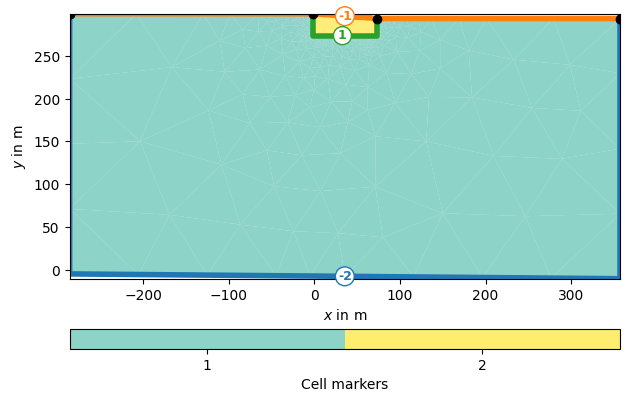

In [3]:
mgr = ert.ERTManager(data)
mesh = mt.createParaMesh(data.sensorPositions(), paraDX=0.33, paraDepth=20, paraMaxCellSize=0.75)

mgr.setMesh(mesh)
print(mesh)
pg.show(mesh, markers=True)

## 4.2) Define inversion mesh and geostatistical parameters

One flaw of the current implementation of the geostatistical constraints in pyGIMLi is the fact that it only takes one model region as input and cannot differentiate between several regions.

Thus, we have to set all cell markers of our mesh to the same value in order for the covariance matrix to be successfully constructed.

Afterwards, we can set the geostatistical parameters in the `mgr.invert()` function.

We take the following assumptions:

* We have strongly pronounced horizontal layering at the site. This is already visible in the individual ERT inversion result.
*  Our layers are close to horizontal and do not show a distinct dipping angle.

Based on these assumptions, we set the correlation lengths to 5 m in x- and 1 m in y-direction and the dip angle to 0°. Feel free to experiment around with the values and see their effect! 

We start by visualizing the geostatisitcal operator for a specific model cell. 

For this, we create the constraint matrix **C** and extract the row that corresponds to a cell at *x=35 m* and *y=290 m*:

In [4]:
for c in mesh.cells():
    c.setMarker(1)

C = pg.matrix.GeostatisticConstraintsMatrix(mesh=mesh, I=[5,1], dip=0)
ind = mesh.findCell([35, 290]).id()
vec = pg.Vector(mesh.cellCount())
vec[ind] = 1.0
cor = C * vec

18/09/26 - 09:00:30 - pyGIMLi - INFO - (C) Time for eigenvalue decomposition 145.0s
18/09/26 - 09:00:30 - pyGIMLi - INFO - Cache stored: C:\Users\Nino Menzel\AppData\Roaming\pygimli\Cache\732746466145741369


c:\Users\Nino Menzel\.venv\Lib\site-packages\pygimli\viewer\mpl\utils.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.tight_layout()


Text(0.5, 311.8605077688272, 'Profile length (m)')

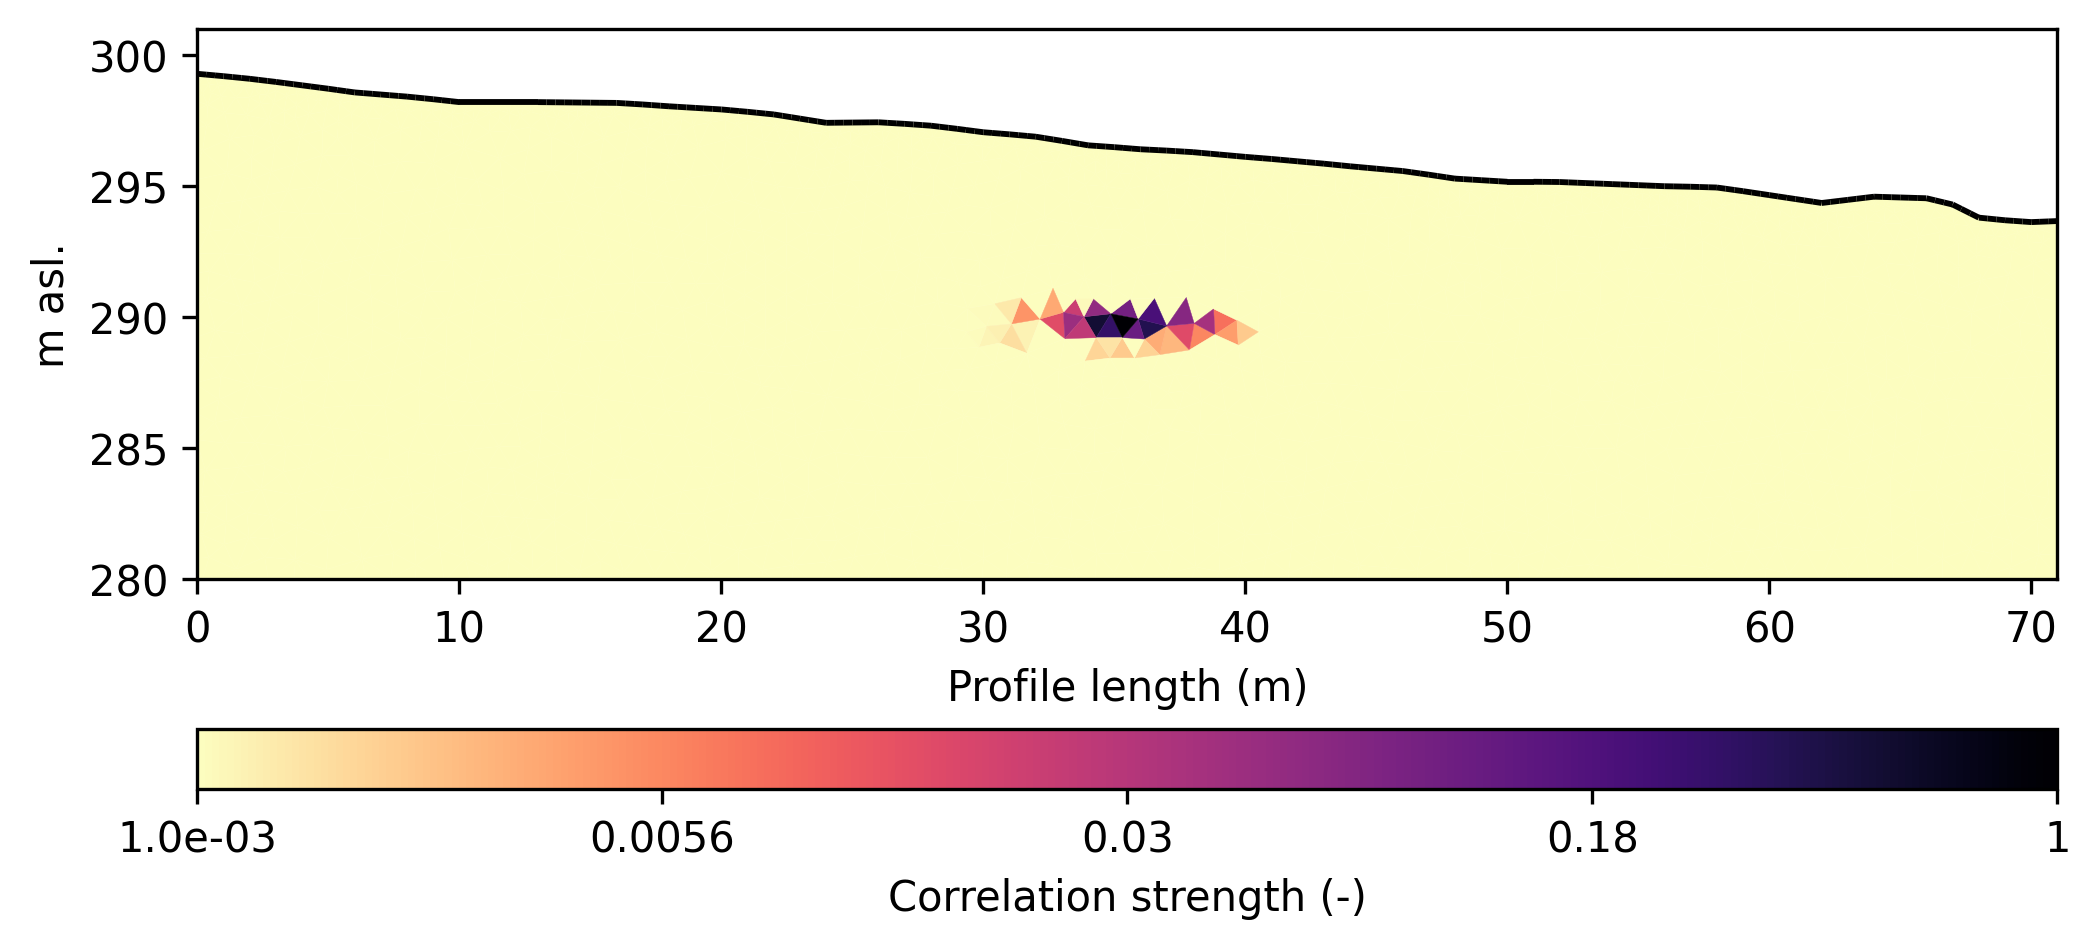

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=300, sharex=True, gridspec_kw={'hspace': .1})
kwLog = dict(cMin=1e-3, cMax=1, cMap="magma_r", logScale=True, label="Correlation strength (-)")

pg.show(mesh, np.abs(cor), ax=ax, **kwLog)
ax.set_ylim(280, 301)
ax.set_xlim(0, 71)

ax.set_ylabel("m asl.")
ax.set_xlabel("Profile length (m)")

Next up, we utilize the estimated geostatistical parameters in the inversion:

In [6]:
invArgs = dict(lam = 45, verbose=True, correlationLengths=[5,1], dip=0)

mgr = ert.ERTManager(data)
inv = mgr.invert(mesh=mesh, **invArgs)

18/09/26 - 09:00:38 - pyGIMLi - INFO - Found 1 regions.
18/09/26 - 09:00:38 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 09:00:38 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
18/09/26 - 09:00:38 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11361 Cells: 22192 Boundaries: 16908
18/09/26 - 09:00:39 - pyGIMLi - INFO - Use median(data values)=144.315107136596
18/09/26 - 09:00:39 - pyGIMLi - INFO - Created startmodel from forward operator:5548, min/max=144.315107/144.315107
18/09/26 - 09:00:39 - pyGIMLi - INFO - Starting inversion.
18/09/26 - 09:00:39 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000025E7E566570>
18/09/26 - 09:00:39 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
18/09/26 - 09:00:39 - pyGIMLi - INFO - Model transformation (cumulative):
18/09/26 - 09:00:39 - pyGIMLi - INFO - 	 0 Logarithmic LU transform, lower bound 0.0, upper bo

--------------------------------------------------------------------------------


18/09/26 - 09:01:03 - pyGIMLi - INFO - Cache c:\Users\Nino Menzel\.venv\Lib\site-packages\pygimli\math\matrix.py:createCm05 restored (145.0s x 1): C:\Users\Nino Menzel\AppData\Roaming\pygimli\Cache\732746466145741369
18/09/26 - 09:01:15 - pyGIMLi - INFO - inv.iter 0 ... chi² =  413.31


--------------------------------------------------------------------------------
inv.iter 1 ... 

18/09/26 - 09:01:34 - pyGIMLi - INFO - chi² =   81.96 (dPhi = 80.03%) lam: 45.0


...

--------------------------------------------------------------------------------
inv.iter 3 ... 

18/09/26 - 09:02:35 - pyGIMLi - INFO - chi² =    1.11 (dPhi = 57.36%) lam: 45.0


--------------------------------------------------------------------------------
inv.iter 4 ... 

18/09/26 - 09:03:03 - pyGIMLi - INFO - chi² =    0.98 (dPhi = 6.22%) lam: 45.0




################################################################################
#                  Abort criterion reached: chi² <= 1 (0.98)                   #
################################################################################


## 4.3) Load smoothness-constrained ERT inversion result and compare to geostatistically constrained result

Comparing the smoothness-constrained and the geostatistically constrained models, we can clearly see the effect of including a-priori information about the structural covariance at our site.

The horizontal layering near the surface is more pronounced and layer transitions are displayed sharper than before.
In the lower right corner of the geostatisitcally constrained model, we see a more conductive area, hinting towards a change to probably a more water-saturated region of the Devonian hard rock. 

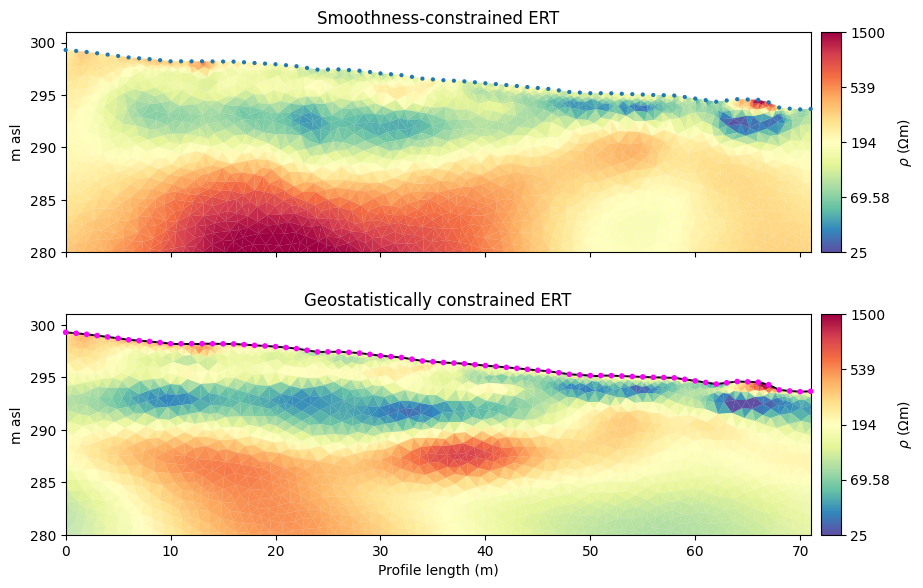

In [7]:
smooth_ERT = pg.load("../data/inv_ERT.vtk")

rKW = dict(logScale=True, cMin=25, cMax=1500, cMap="Spectral_r",
           orientation="vertical", label = r"$\rho$ ($\Omega$m)")

fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10, 7),sharex=True, gridspec_kw={'hspace': .1})

pg.show(smooth_ERT, smooth_ERT["Resistivity"], ax=ax1, **rKW)
pg.viewer.mpl.drawSensors(ax1, data.sensors())
ax1.set_ylim(280, 301)
ax1.set_xlim(0, 71)
ax1.set_ylabel("m asl")
ax1.set_title("Smoothness-constrained ERT")
ax1.set_xlabel("")
ax1.set_aspect("equal")


mgr.showResult(ax=ax2, **rKW)
ax2.set_ylim(280, 301)
ax2.set_xlim(0, 71)
ax2.set_ylabel("m asl")
ax2.set_xlabel("Profile length (m)")
ax2.set_title("Geostatistically constrained ERT")
ax2.set_aspect("equal")